In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [82]:
df = pd.read_csv("divorce.csv", sep=";")
print(df.head())

   Atr1  Atr2  Atr3  Atr4  Atr5  Atr6  Atr7  Atr8  Atr9  Atr10  ...  Atr46  \
0     2     2     4     1     0     0     0     0     0      0  ...      2   
1     4     4     4     4     4     0     0     4     4      4  ...      2   
2     2     2     2     2     1     3     2     1     1      2  ...      3   
3     3     2     3     2     3     3     3     3     3      3  ...      2   
4     2     2     1     1     1     1     0     0     0      0  ...      2   

   Atr47  Atr48  Atr49  Atr50  Atr51  Atr52  Atr53  Atr54  Class  
0      1      3      3      3      2      3      2      1      1  
1      2      3      4      4      4      4      2      2      1  
2      2      3      1      1      1      2      2      2      1  
3      2      3      3      3      3      2      2      2      1  
4      1      2      3      2      2      2      1      0      1  

[5 rows x 55 columns]


In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Atr1,170.0,1.776471,1.627257,0.0,0.0,2.0,3.0,4.0
Atr2,170.0,1.652941,1.468654,0.0,0.0,2.0,3.0,4.0
Atr3,170.0,1.764706,1.415444,0.0,0.0,2.0,3.0,4.0
Atr4,170.0,1.482353,1.504327,0.0,0.0,1.0,3.0,4.0
Atr5,170.0,1.541176,1.632169,0.0,0.0,1.0,3.0,4.0
Atr6,170.0,0.747059,0.904046,0.0,0.0,0.0,1.0,4.0
Atr7,170.0,0.494118,0.898698,0.0,0.0,0.0,1.0,4.0
Atr8,170.0,1.452941,1.546371,0.0,0.0,1.0,3.0,4.0
Atr9,170.0,1.458824,1.557976,0.0,0.0,1.0,3.0,4.0
Atr10,170.0,1.576471,1.421529,0.0,0.0,2.0,3.0,4.0


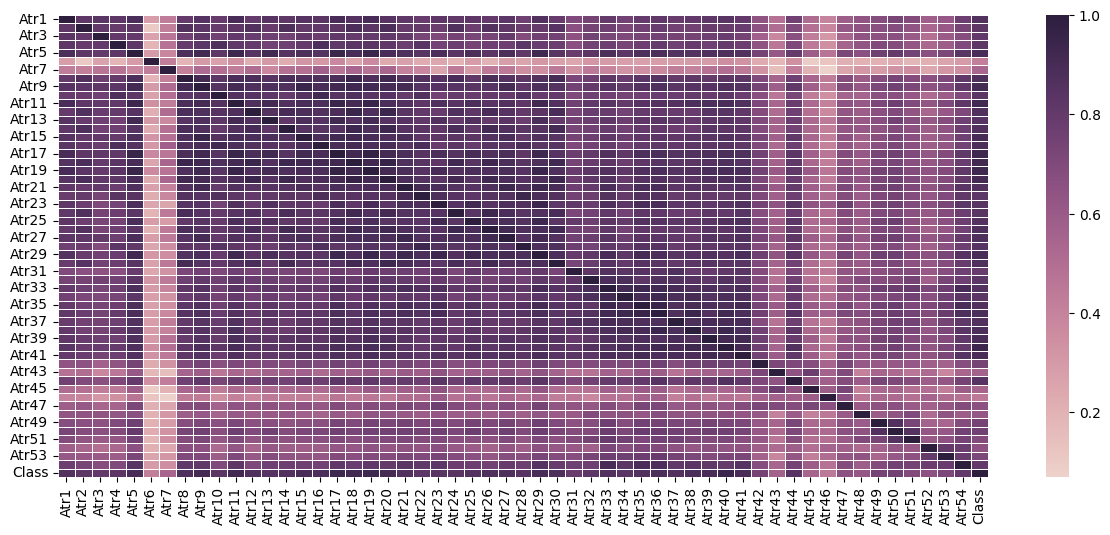

In [84]:
plt.figure(figsize=(15,6)) #plot the heatmap for the correlation
sns.heatmap(df.corr(),fmt=".5f", linewidth=.5, cmap=sns.cubehelix_palette(as_cmap=True)) 
plt.show() #the more darker color the more stronger correlation.

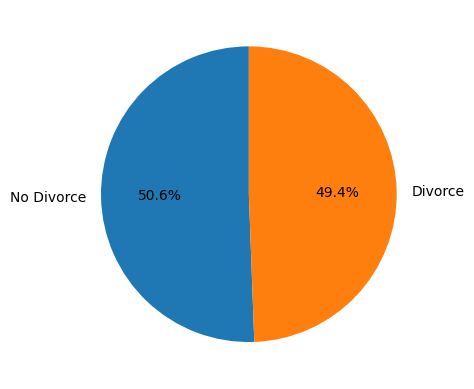

In [85]:
plt.pie(df['Class'].value_counts(), labels=['No Divorce', 'Divorce'], autopct='%1.1f%%', startangle=90)
plt.show()

In [86]:
df.corr()['Class'].sort_values(ascending=False).head(10)

Class    1.000000
Atr40    0.938684
Atr17    0.929346
Atr19    0.928627
Atr18    0.923208
Atr11    0.918386
Atr9     0.912368
Atr20    0.907008
Atr15    0.901220
Atr39    0.896180
Name: Class, dtype: float64

## AS WE CAN SEE THESE QUESTIONS ARE VERY CORRELATED 

In [87]:
X = df.drop(columns=['Class'])
y = df['Class']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [89]:
train_data = X_train.copy()
train_data['Class'] = y_train

##SPLITING MY DATA FIRST SO THAT THERE IS NO LEAKAGE 

In [90]:
train_corr = train_data.corr()['Class']

In [91]:
columns_to_drop = train_corr[train_corr < 0.90].index
columns_to_drop = columns_to_drop.drop('Class', errors='ignore')

In [92]:
print(list(columns_to_drop))

['Atr1', 'Atr2', 'Atr3', 'Atr4', 'Atr6', 'Atr7', 'Atr8', 'Atr10', 'Atr12', 'Atr13', 'Atr14', 'Atr16', 'Atr21', 'Atr22', 'Atr23', 'Atr24', 'Atr25', 'Atr26', 'Atr27', 'Atr28', 'Atr30', 'Atr31', 'Atr32', 'Atr33', 'Atr34', 'Atr35', 'Atr36', 'Atr37', 'Atr38', 'Atr39', 'Atr42', 'Atr43', 'Atr44', 'Atr45', 'Atr46', 'Atr47', 'Atr48', 'Atr49', 'Atr50', 'Atr51', 'Atr52', 'Atr53', 'Atr54']


In [93]:
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop) 

In [94]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (136, 11)
Testing shape: (34, 11)


In [95]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



# Create AdaBoost classifier
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)  # You can adjust parameters like n_estimators

# Train the model
adaboost.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = adaboost.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9411764705882353


In [96]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(adaboost, X_train, y_train, cv=20)  # You can adjust the number of folds (cv parameter)

# Print cross-validation scores
print("Cross-validation scores:", cv_scores)

# Print mean accuracy and standard deviation of cross-validation scores
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation of Accuracy:", cv_scores.std())

Cross-validation scores: [1.         1.         1.         1.         0.85714286 1.
 1.         1.         1.         1.         0.85714286 1.
 1.         1.         1.         0.85714286 1.         1.
 1.         1.        ]
Mean Accuracy: 0.9785714285714286
Standard Deviation of Accuracy: 0.05101020306102038
